In [1]:
import pandas as pd
import numpy as np
import os
from matplotlib import cm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
#import matplotlib.lines as mlines
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, PercentFormatter)
from mpl_toolkits.axes_grid1 import make_axes_locatable

# working dir
work_path = "C:/Users/wenlou/Documents/Python Scripts"
os.chdir(work_path)
from help_function import *
data_path = "C:/Users/wenlou/Documents/MATLAB/Prediction/explainAV"
#pred_path = 'C:/Users/wenlou/Documents/MATLAB/Prediction'

In [2]:
# process behavioural data
extent = (-12, 12, 12, -12)
def avg_z(df, varC, varConf, n=4):
    agg_bysub = df.groupby(['s_a', 's_v', 'sub_id'])[[varC, varConf]].mean().reset_index()
    agg = agg_bysub.groupby(['s_a', 's_v'])[[varC, varConf]].mean().reset_index()
    Z = agg[varC].values.reshape(n, -1).T
    Zconf = agg[varConf].values.reshape(n, -1).T
    return Z, Zconf

In [42]:
sub_id =34
df_beh = processBehDat()
df_beh['ComSourFlag'] = 2 - df_beh['ComSourFlag']
#Z_beh, Zconf_beh = avg_z(df_beh, 'ComSourFlag','confLvl')
# _, Zconf_beh_com = avg_z(df_beh.loc[df_beh.ComSourFlag==1], 'ComSourFlag','confLvl')
# _, Zconf_beh_sep = avg_z(df_beh.loc[df_beh.ComSourFlag==0], 'ComSourFlag','confLvl')
Z_beh, Zconf_beh = avg_z(df_beh.loc[df_beh['sub_id'] == sub_id], 'ComSourFlag','confLvl')


In [7]:
df_beh

,sub_id,delta_VA,confLvl,ComSourLbl,ComSourFlag,s_a,s_v,ConfLbl
0,1,-8,2,Separate,0,4,-4,Medium
1,1,8,2,Common,1,4,12,Medium
2,1,-16,2,Separate,0,4,-12,Medium
3,1,-8,2,Separate,0,-4,-12,Medium
4,1,0,2,Common,1,-4,-4,Medium
...,...,...,...,...,...,...,...,...
8699,45,-24,3,Separate,0,12,-12,High
8700,45,-16,3,Separate,0,12,-4,High
8701,45,0,3,Common,1,12,12,High
8702,45,-16,3,Separate,0,12,-4,High


In [11]:
m_label = {'Bay-Bay': 70, 'xDiff-xDiff': 74}
# sub_id = 38
# sub_lst = [sub_id]
sub_lst = read_sub_lst()

df_sim_bay = processPredDat(m_label['Bay-Bay'], sub_lst)
df_sim_bay['R_pc'] = 2 - df_sim_bay['R_pc']

df_sim_xdiff = processPredDat(m_label['xDiff-xDiff'], sub_lst)
df_sim_xdiff['R_pc'] = 2 - df_sim_xdiff['R_pc']

In [12]:
# Z_sim_bay, Zconf_bay = avg_z(df_sim_bay, 'R_pc','R_conf')
# Z_sim_xdiff, Zconf_xdiff = avg_z(df_sim_xdiff, 'R_pc','R_conf')
sub_id =34
Z_sim_bay, Zconf_bay = avg_z(df_sim_bay.loc[df_sim_bay['sub_id'] == sub_id], 'R_pc','R_conf')
Z_sim_xdiff, Zconf_xdiff = avg_z(df_sim_xdiff.loc[df_sim_xdiff['sub_id'] == sub_id], 'R_pc','R_conf')

In [7]:
df_sim_bay

,prob,rec,s_a,s_v,s_uni,tr_f,R_pc,R_conf,R_s,sub_id,delta_VA,ComSourLbl,ConfLbl
0,0.754608,8.933270,-12,-12,-12,1,1,2,-4,1,0,Common,Medium
1,0.763453,7.435707,-12,-12,-12,1,1,3,-4,1,0,Common,High
2,0.249472,10.867328,-12,-12,-12,1,0,2,-4,1,0,Separate,Medium
3,0.725401,0.040875,-12,-12,-12,1,1,2,-12,1,0,Common,Medium
4,0.613370,-4.657235,-12,-12,-12,1,1,2,-12,1,0,Common,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4351995,0.868964,2.048352,12,12,12,0,1,3,12,45,0,Common,High
4351996,0.807871,-2.764255,12,12,12,0,1,3,12,45,0,Common,High
4351997,0.110092,0.551134,12,12,12,0,0,3,12,45,0,Separate,High
4351998,0.985408,-2.819253,12,12,12,0,1,3,12,45,0,Common,High


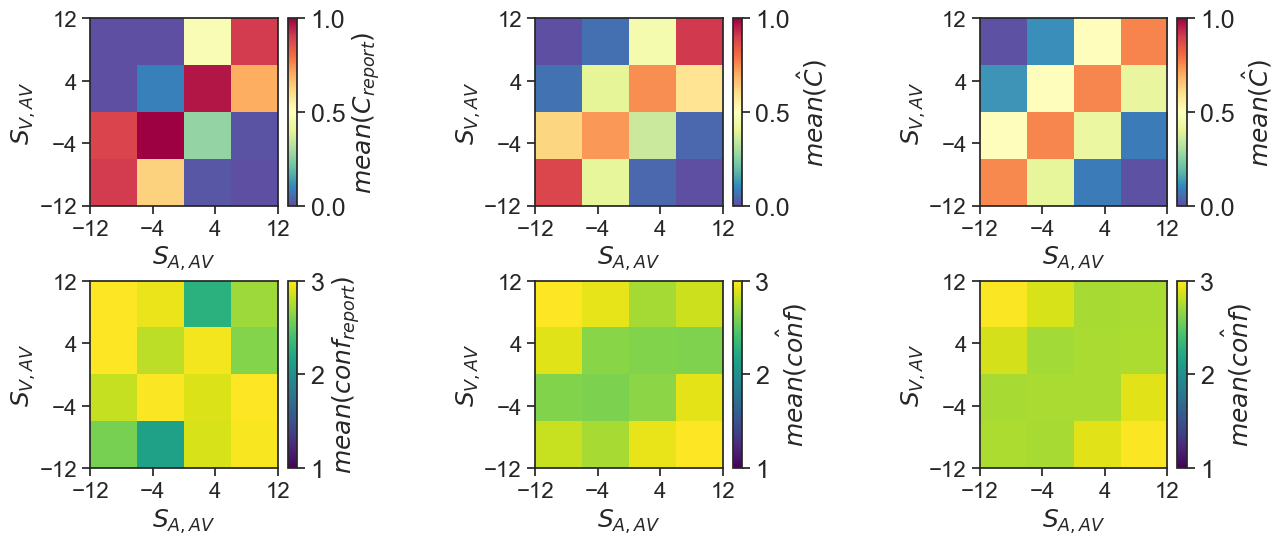

In [44]:
fig, _axs = plt.subplots(figsize = (14, 6), nrows=2, ncols=3)
fig.subplots_adjust(hspace=0.4, wspace = 0.2, left=0.05, right = 0.95, top=0.9, bottom = 0.15)

axs = _axs.flatten()
cmap = cm.Spectral  

im = [None]*6
cbar=[None]*6

im[0]=axs[0].imshow(Z_beh, extent=extent, interpolation=None, cmap=cm.Spectral.reversed(), norm = cm.colors.Normalize(vmax=1, vmin=0))
ylim = axs[0].get_ylim()
im[1]=axs[1].imshow(Z_sim_bay, extent=extent, interpolation=None, cmap=cm.Spectral.reversed(), norm = cm.colors.Normalize(vmax=1, vmin=0))
im[2]=axs[2].imshow(Z_sim_xdiff, extent = extent, interpolation = None, cmap= cm.Spectral.reversed(), norm = cm.colors.Normalize(vmax=1, vmin=0))

im[3]=axs[3].imshow(Zconf_beh, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))
ylim = axs[3].get_ylim()
im[4]=axs[4].imshow(Zconf_bay, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))
im[5]=axs[5].imshow(Zconf_xdiff, extent = extent, interpolation = None, cmap= cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))


fontsize=18
for i in np.arange(6):
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust size and padding
    cbar[i] = fig.colorbar(im[i], cax= cax)
    cbar[i].ax.tick_params(labelsize=fontsize)

for ax in axs:
    ax.xaxis.set_major_locator(MultipleLocator(4))
    ax.set_xticks([-12, -4, 4, 12])
    ax.yaxis.set_major_locator(MultipleLocator(4))
    ax.set_yticks([-12, -4, 4, 12])
    ax.tick_params(axis='both', which='major', direction='out', left=True, bottom=True, labelsize=16)
    ax.set_ylim(ylim[::-1])
    ax.set_xlabel(r'$S_{A,AV}$',fontsize = fontsize)
    ax.set_ylabel(r'$S_{V,AV}$',fontsize = fontsize, labelpad=1)

cbar[0].set_label(r'$mean(C_{report})$', fontsize=fontsize) 
cbar[1].set_label(r'$mean(\hat{C})$', fontsize=fontsize) 
cbar[2].set_label(r'$mean(\hat{C})$', fontsize=fontsize) 
cbar[3].set_label(r'$mean(conf_{report})$', fontsize=fontsize) 
cbar[4].set_label(r'$mean(\hat{conf})$', fontsize=fontsize) 
cbar[5].set_label(r'$mean(\hat{conf})$', fontsize=fontsize) 
# axs[0].set_title('Behavioral Data - Combined', fontsize=fontsize)
# axs[1].set_title('Behavioral Data - Common Source', fontsize=fontsize)
# axs[2].set_title('Behavioral Data - Separate Source', fontsize=fontsize)

#plt.suptitle('Subject ' + str(sub_id), fontsize=20, y=0.95)
plt.savefig(os.path.join(work_path, 'plot4paper', 'AV_explain08262026.png'), dpi=300)
plt.show()

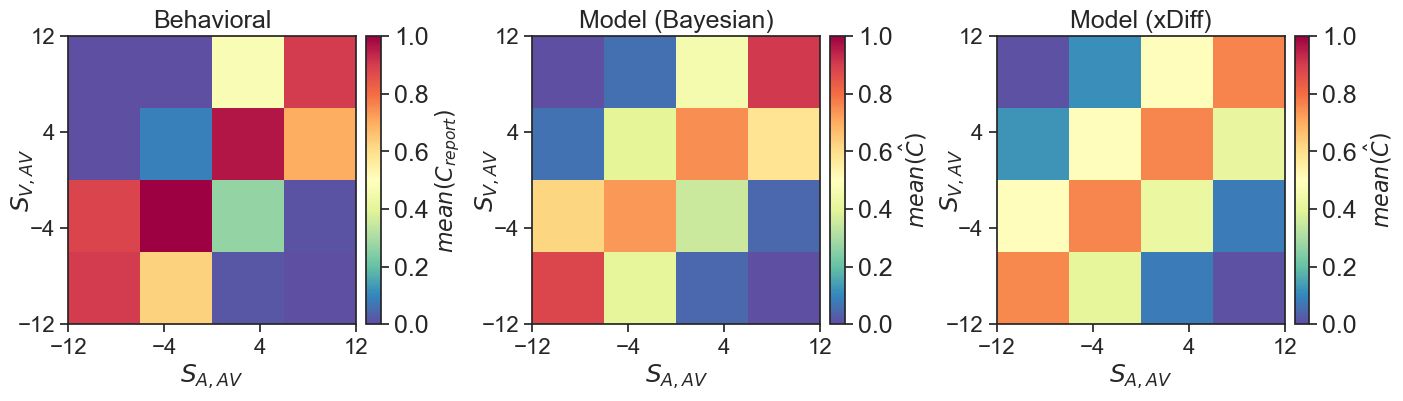

In [45]:
fig, _axs = plt.subplots(figsize = (14, 4), nrows=1, ncols=3)
fig.subplots_adjust( wspace = 0.4, left=0.05, right = 0.95, top=0.9, bottom = 0.18)

axs = _axs.flatten()
cmap = cm.Spectral  

im = [None]*3
cbar=[None]*3

im[0]=axs[0].imshow(Z_beh, extent=extent, interpolation=None, cmap=cm.Spectral.reversed(), norm = cm.colors.Normalize(vmax=1, vmin=0))
ylim = axs[0].get_ylim()
im[1]=axs[1].imshow(Z_sim_bay, extent=extent, interpolation=None, cmap=cm.Spectral.reversed(), norm = cm.colors.Normalize(vmax=1, vmin=0))
im[2]=axs[2].imshow(Z_sim_xdiff, extent = extent, interpolation = None, cmap= cm.Spectral.reversed(), norm = cm.colors.Normalize(vmax=1, vmin=0))

# im[3]=axs[3].imshow(Zconf_beh, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))
# ylim = axs[3].get_ylim()
# im[4]=axs[4].imshow(Zconf_bay, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))
# im[5]=axs[5].imshow(Zconf_xdiff, extent = extent, interpolation = None, cmap= cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))


fontsize=18
for i in np.arange(3):
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust size and padding
    cbar[i] = fig.colorbar(im[i], cax= cax)
    cbar[i].ax.tick_params(labelsize=fontsize)

for ax in axs:
    ax.xaxis.set_major_locator(MultipleLocator(4))
    ax.set_xticks([-12, -4, 4, 12])
    ax.yaxis.set_major_locator(MultipleLocator(4))
    ax.set_yticks([-12, -4, 4, 12])
    ax.tick_params(axis='both', which='major', direction='out', left=True, bottom=True, labelsize=16)
    ax.set_ylim(ylim[::-1])
    ax.set_xlabel(r'$S_{A,AV}$',fontsize = fontsize)
    ax.set_ylabel(r'$S_{V,AV}$',fontsize = fontsize, labelpad=-15)

cbar[0].set_label(r'$mean(C_{report})$', fontsize=fontsize-2) 
cbar[1].set_label(r'$mean(\hat{C})$', fontsize=fontsize-2) 
cbar[2].set_label(r'$mean(\hat{C})$', fontsize=fontsize-2) 
axs[0].set_title('Behavioral', fontsize=fontsize)
axs[1].set_title('Model (Bayesian)', fontsize=fontsize)
axs[2].set_title('Model (xDiff)', fontsize=fontsize)
# cbar[3].set_label(r'$mean(conf_{report})$', fontsize=fontsize) 
# cbar[4].set_label(r'$mean(\hat{conf})$', fontsize=fontsize) 
# cbar[5].set_label(r'$mean(\hat{conf})$', fontsize=fontsize) 
# axs[0].set_title('Behavioral Data - Combined', fontsize=fontsize)
# axs[1].set_title('Behavioral Data - Common Source', fontsize=fontsize)
# axs[2].set_title('Behavioral Data - Separate Source', fontsize=fontsize)

#plt.suptitle('Subject ' + str(sub_id), fontsize=20, y=0.95)
plt.savefig(os.path.join(work_path, 'plot4paper', 'AV_explain08262026_half.png'), dpi=300)
plt.show()

In [5]:
df_sim_bay

,prob,rec,s_a,s_v,s_uni,tr_f,R_pc,R_conf,R_s,sub_id,delta_VA,ComSourLbl,ConfLbl
0,0.454130,0.825605,-12,-12,-12,1,0,1,-12,1,0,Separate,Low
1,0.893807,-3.073128,-12,-12,-12,1,1,3,-12,1,0,Common,High
2,0.822368,7.261595,-12,-12,-12,1,1,3,-4,1,0,Common,High
3,0.712753,4.720480,-12,-12,-12,1,1,2,-4,1,0,Common,Medium
4,0.568001,1.085856,-12,-12,-12,1,1,1,-12,1,0,Common,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21759995,0.883494,-0.457088,12,12,12,0,1,3,12,45,0,Common,High
21759996,0.966259,-3.102623,12,12,12,0,1,3,12,45,0,Common,High
21759997,0.928208,0.006650,12,12,12,0,1,3,12,45,0,Common,High
21759998,0.589035,-0.706165,12,12,12,0,1,2,12,45,0,Common,Medium


In [4]:
# statistical tests
from scipy.stats import wilcoxon
df_beh_test = df_beh.loc[df_beh.ComSourFlag==1].groupby(['s_a', 's_v', 'sub_id'])['confLvl'].mean().reset_index()
df_beh_test = df_beh_test.loc[df_beh_test.s_a == df_beh_test.s_v]
df_beh_test['center_f'] = np.where(df_beh_test.s_a.abs() <=4, 1, 0)
df_beh_test = df_beh_test.groupby(['center_f', 'sub_id'])['confLvl'].mean().reset_index()
df_beh_test

,center_f,sub_id,confLvl
0,0,1,2.454756
1,0,2,2.201697
2,0,3,2.803030
3,0,4,2.771739
4,0,5,2.543179
...,...,...,...
63,1,39,2.862714
64,1,41,2.928674
65,1,43,2.585671
66,1,44,2.857194


In [6]:
wide = (
    df_beh_test
    .pivot(index='sub_id', columns='center_f', values='confLvl')
    .dropna()
)

# center_f == 1 is "central", 0 is "peripheral"
stat, p = wilcoxon(
    wide[1],
    wide[0],
    alternative='greater'
)

print(stat, p)


436.0 0.008461100340355188


In [42]:
Zconf_beh_com

array([[2.5778423 , 2.34953125, 2.11576457, 2.28122032],
       [2.60965446, 2.72683982, 2.49778413, 2.63129916],
       [2.45806314, 2.42950765, 2.67968244, 2.61330359],
       [2.47256892, 2.09206599, 2.27106446, 2.53784449]])

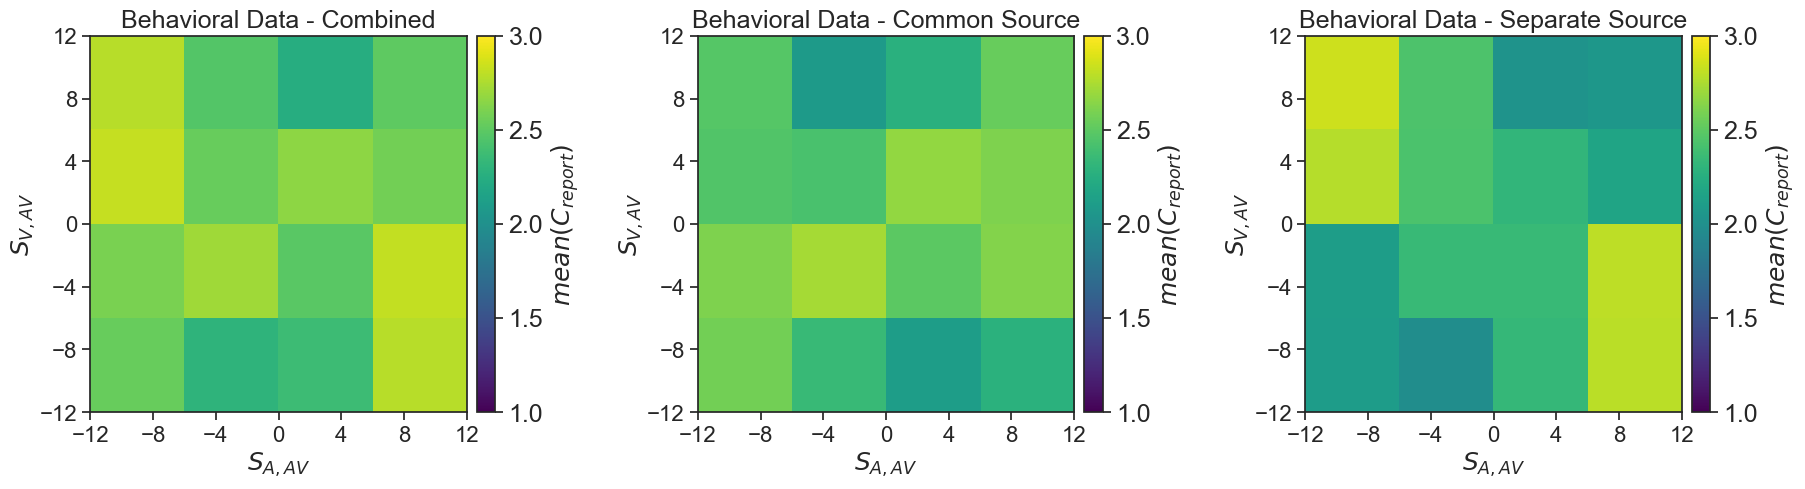

In [35]:
fig, _axs = plt.subplots(figsize = (18, 6), nrows=1, ncols=3)
fig.subplots_adjust(wspace = 0.5, left=0.05, right = 0.95, top=0.9, bottom = 0.1)
axs = _axs.flatten()

cmap = cm.Spectral  

im = [None]*3
cbar=[None]*3

im[0]=axs[0].imshow(Zconf_beh, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))
ylim = axs[0].get_ylim()
im[1]=axs[1].imshow(Zconf_beh_com, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))
im[2]=axs[2].imshow(Zconf_beh_sep, extent = extent, interpolation = None, cmap= cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))

fontsize=18
for i in np.arange(3):
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust size and padding
    cbar[i] = fig.colorbar(im[i], cax= cax)
    cbar[i].ax.tick_params(labelsize=fontsize)

for ax in axs:
    ax.xaxis.set_major_locator(MultipleLocator(4))
    ax.yaxis.set_major_locator(MultipleLocator(4))
    ax.tick_params(axis='both', which='major', direction='out', left=True, bottom=True, labelsize=16)
    ax.set_ylim(ylim[::-1])
    ax.set_xlabel(r'$S_{A,AV}$',fontsize = fontsize)
    ax.set_ylabel(r'$S_{V,AV}$',fontsize = fontsize, labelpad=1)

cbar[0].set_label(r'$mean(C_{report})$', fontsize=fontsize) 
cbar[1].set_label(r'$mean(C_{report})$', fontsize=fontsize) 
cbar[2].set_label(r'$mean(C_{report})$', fontsize=fontsize) 
axs[0].set_title('Behavioral Data - Combined', fontsize=fontsize)
axs[1].set_title('Behavioral Data - Common Source', fontsize=fontsize)
axs[2].set_title('Behavioral Data - Separate Source', fontsize=fontsize)

#plt.suptitle('Subject ' + str(sub_id), fontsize=20, y=0.95)
#plt.savefig(os.path.join(work_path, 'plot4paper', 'AV_explain0417.png'), dpi=300)
plt.show()

In [37]:
m_label = {'Bay-Bay': 70, 'xDiff-xDiff': 74}

#prepare data

# the image value is the mean prob
delta = 0.5    
sa = np.arange(-12.0, 12.001, delta)
SA, SV = np.meshgrid(sa, sa)
extent = (-12, 12, 12, -12)

# process sim data
df_sim = pd.read_csv(os.path.join(data_path, 'pred_explainAV_m_' + str(m_label['Bay-Bay']) + '.csv')) 
agg_prob = df_sim.groupby(['s_a', 's_v'])[['prob']].mean().reset_index()
Z_bay = agg_prob['prob'].values.reshape(49, -1).T
Zconf_bay = np.maximum(Z_bay, 1-Z_bay)

agg_prob_com = df_sim.loc[df_sim.R_pc==1].groupby(['s_a', 's_v'])[['prob']].mean().reset_index()
Zconfcom_bay = agg_prob_com['prob'].values.reshape(49, -1).T
agg_prob_sep = df_sim.loc[df_sim.R_pc==2].groupby(['s_a', 's_v'])[['prob']].mean().reset_index()
Zconfsep_bay = 1-agg_prob_sep['prob'].values.reshape(49, -1).T

df_sim = pd.read_csv(os.path.join(data_path, 'pred_explainAV_m_' + str(m_label['xDiff-xDiff']) + '.csv')) 
df_sim['xdiff'] = abs(df_sim['bi_xA'] - df_sim['bi_xV'])
agg_xdiff = df_sim.groupby(['s_a', 's_v'])[['xdiff']].mean().reset_index()
epsilon = 11
Z_xdiff = epsilon - agg_xdiff['xdiff'].values.reshape(49, -1).T
Zconf_xdiff = abs(Z_xdiff)

agg_prob_com = df_sim.loc[df_sim.R_pc==1].groupby(['s_a', 's_v'])[['xdiff']].mean().reset_index()
Zconfcom_xdiff = agg_prob_com['xdiff'].values.reshape(49, -1).T
agg_prob_sep = df_sim.loc[df_sim.R_pc==2].groupby(['s_a', 's_v'])[['xdiff']].mean().reset_index()
Zconfsep_xdiff = agg_prob_sep['xdiff'].values.reshape(49, -1).T


In [30]:
# process beh data 
def avg_zcount(df, varC, n=4):
    agg_bysub = df.groupby(['s_a', 's_v', 'sub_id'])[varC].count().reset_index()
    agg = agg_bysub.groupby(['s_a', 's_v'])[varC].mean().reset_index()
    Z_bay = agg[varC].values.reshape(n, -1).T
    return Z_bay

In [29]:
df = df_beh
agg_bysub = df.groupby(['s_a', 's_v', 'sub_id', 'ComSourFlag'])['ComSourLbl'].count().reset_index()
agg_bysub['ComSourLbl'] = agg_bysub['ComSourLbl'] / 112 / 16 # total trial num per cond per sub
agg = agg_bysub.groupby(['s_a', 's_v', 'ComSourFlag'])['ComSourLbl'].sum().reset_index()
agg['ComSourLbl'] = agg['ComSourLbl'] / 34  # number of subjects
Z_count_sep = agg.loc[agg.ComSourFlag == 0].sort_values(by=['s_a', 's_v'], ascending = [True, False])['ComSourLbl'].values.reshape(4, -1).T
Z_count_com = agg.loc[agg.ComSourFlag == 1].sort_values(by=['s_a', 's_v'], ascending = [True, False])['ComSourLbl'].values.reshape(4, -1).T
# Z_count_sep = agg.loc[agg.ComSourFlag == 0,'ComSourLbl'].values.reshape(4, -1).T
# Z_count_com = agg.loc[agg.ComSourFlag == 1,'ComSourLbl'].values.reshape(4, -1).T
Z_count_com

array([[0.00745142, 0.01834953, 0.04743304, 0.05770746],
       [0.00869879, 0.02568606, 0.05857734, 0.05366991],
       [0.05133929, 0.05869223, 0.03408942, 0.00735294],
       [0.05462185, 0.04682576, 0.02133666, 0.00428374]])

In [40]:
Z_count_sep.round(4)

array([[0.055 , 0.0442, 0.0151, 0.0048],
       [0.0538, 0.0368, 0.0039, 0.0088],
       [0.0112, 0.0038, 0.0284, 0.0551],
       [0.0079, 0.0157, 0.0412, 0.0582]])

In [41]:
Z_count_com.round(4)

array([[0.0075, 0.0183, 0.0474, 0.0577],
       [0.0087, 0.0257, 0.0586, 0.0537],
       [0.0513, 0.0587, 0.0341, 0.0074],
       [0.0546, 0.0468, 0.0213, 0.0043]])

In [ ]:
fig, _axs = plt.subplots(figsize = (18, 10), nrows=2, ncols=3)
fig.subplots_adjust(hspace=0.3, wspace = 0.3, left=0.05, right = 0.95, top=0.9, bottom = 0.1)
axs = _axs.flatten()

#norm_prob = cm.colors.Normalize(vmax=max(abs(Z_bay).max(), abs(Zconf_bay).max()), vmin=min(abs(Z_bay).min(), abs(Zconf_bay).min()))
#norm_xdiff = cm.colors.Normalize(vmax=max(abs(Z_xdiff).max(), abs(Zconf_xdiff).max()), vmin=min(abs(Z_xdiff).min(), abs(Zconf_xdiff).min()))
cmap = cm.Spectral  

c =  [None]*6
im = [None]*6
cbar=[None]*6

im[0]=axs[0].imshow(Zconf_beh_com, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))
ylim = axs[0].get_ylim()

#c[1] = axs[1].contour(SA, SV, Zconfcom_bay, (0.6,  0.75 ), colors='k', linewidths=2)
im[1]=axs[1].imshow(Zconfcom_bay, extent=extent, interpolation='bilinear', cmap=cm.viridis, norm = cm.colors.Normalize(vmax=1, vmin=0.5))

#c[2]=axs[2].contour(SA, SV, Zconfcom_xdiff, (1, 4.2), colors = 'k', linewidths= 2)
im[2]=axs[2].imshow(Zconfcom_xdiff, extent = extent, interpolation = 'bilinear', cmap= cm.viridis)

im[3]=axs[3].imshow(Zconf_beh_sep, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))

#c[4] = axs[4].contour(SA, SV, Zconfsep_bay, (0.6,  0.75 ), colors='k', linewidths=2)
im[4]=axs[4].imshow(Zconfsep_bay, extent=extent, interpolation='bilinear', cmap=cm.viridis)

#c[5] = axs[5].contour(SA, SV, Zconfsep_xdiff, (1, 4.2), colors='k', linewidths=2)
im[5]=axs[5].imshow(Zconfsep_xdiff, extent=extent, interpolation='bilinear', cmap=cm.viridis)

fontsize=18
for i in np.arange(6):
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust size and padding
    # if i not in [0, 3]:
    #     axs[i].clabel(c[i], fontsize=fontsize)
    cbar[i] = fig.colorbar(im[i], cax= cax)
    cbar[i].ax.tick_params(labelsize=fontsize)

for ax in axs:
    ax.xaxis.set_major_locator(MultipleLocator(4))
    ax.yaxis.set_major_locator(MultipleLocator(4))
    ax.tick_params(axis='both', which='major', direction='out', left=True, bottom=True, labelsize=16)
    ax.set_ylim(ylim[::-1])
    ax.set_xlabel(r'$S_{A,AV}$',fontsize = fontsize)
    ax.set_ylabel(r'$S_{V,AV}$',fontsize = fontsize, labelpad=1)

cbar[0].set_label(r'$mean(C_{report})$', fontsize=fontsize) 
cbar[3].set_label(r'$mean(Conf_{report})$', fontsize=fontsize) 
cbar[1].set_label(r'$P(C=1|x_{A,AV},x_{V,AV})$', fontsize=fontsize)   
cbar[2].set_label(r'$\epsilon - |x_{A,AV} - x_{V,AV}|$', fontsize=fontsize)  
cbar[4].set_label(r'$max(P(C=1|x_{A,AV},x_{V,AV}), $' '\n\t' 
                  r'$P(C=2|x_{A,AV},x_{V,AV}))$', fontsize=fontsize)  
cbar[5].set_label(r'$abs(\epsilon - |x_{A,AV} - x_{V,AV}|)$', fontsize=fontsize)  

#plt.savefig(os.path.join(work_path, 'plot4paper', 'AV_explain0417.png'), dpi=300)
plt.show()

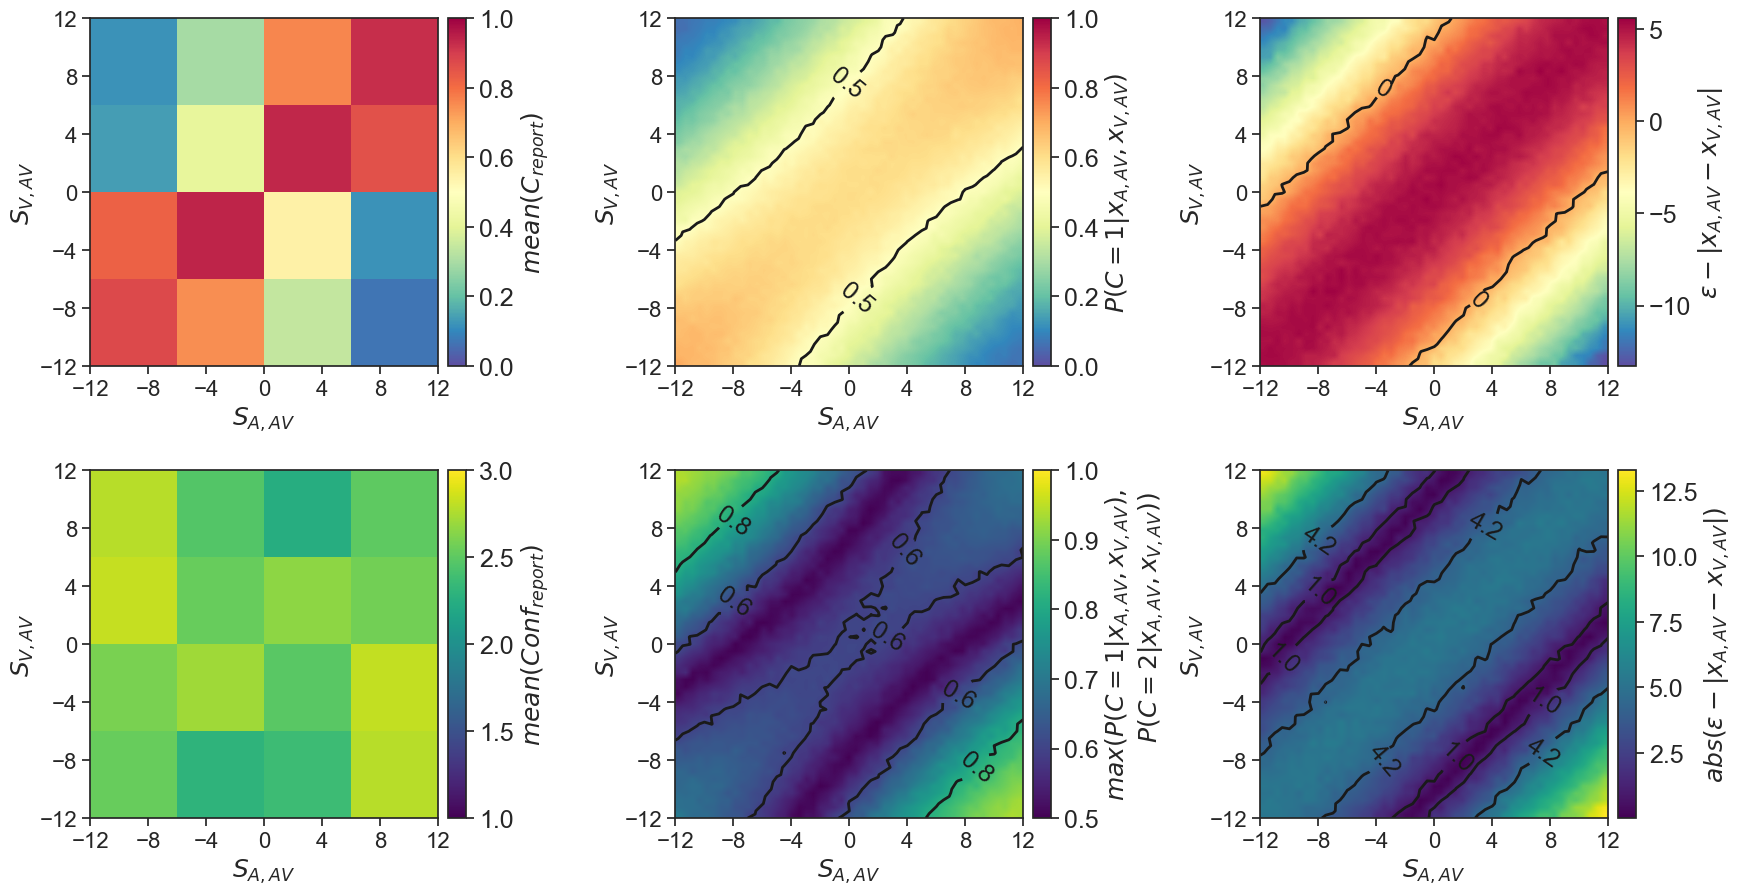

In [38]:
fig, _axs = plt.subplots(figsize = (18, 10), nrows=2, ncols=3)
fig.subplots_adjust(hspace=0.3, wspace = 0.3, left=0.05, right = 0.95, top=0.9, bottom = 0.1)
axs = _axs.flatten()

#norm_prob = cm.colors.Normalize(vmax=max(abs(Z_bay).max(), abs(Zconf_bay).max()), vmin=min(abs(Z_bay).min(), abs(Zconf_bay).min()))
#norm_xdiff = cm.colors.Normalize(vmax=max(abs(Z_xdiff).max(), abs(Zconf_xdiff).max()), vmin=min(abs(Z_xdiff).min(), abs(Zconf_xdiff).min()))
cmap = cm.Spectral  

c =  [None]*6
im = [None]*6
cbar=[None]*6

im[0] = axs[0].imshow(Z_beh, extent=extent, interpolation= None, cmap=cm.Spectral.reversed(), norm = cm.colors.Normalize(vmax=1, vmin=0))
ylim = axs[0].get_ylim()

c[1] = axs[1].contour(SA, SV, Z_bay, (0.5, ),  colors='k', linewidths=2)
im[1] = axs[1].imshow(Z_bay, extent=extent, interpolation='bilinear', cmap=cm.Spectral.reversed(), norm = cm.colors.Normalize(vmax=1, vmin=0))
# ylim = axs[0].get_ylim()

c[2]=axs[2].contour(SA, SV, Z_xdiff, (0,), colors = 'k', linewidths= 2)
im[2]=axs[2].imshow(Z_xdiff, extent = extent, interpolation = 'bilinear', cmap= cm.Spectral.reversed())

im[3]=axs[3].imshow(Zconf_beh, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))

c[4] = axs[4].contour(SA, SV, Zconf_bay, (0.6,  0.8 ), colors='k', linewidths=2)
im[4]=axs[4].imshow(Zconf_bay, extent=extent, interpolation='bilinear', cmap=cm.viridis, norm = cm.colors.Normalize(vmax=1, vmin=0.5))

c[5]=axs[5].contour(SA, SV, Zconf_xdiff, (1, 4.2), colors = 'k', linewidths= 2)
im[5]=axs[5].imshow(Zconf_xdiff, extent = extent, interpolation = 'bilinear', cmap= cm.viridis)
#new
# im[0]=axs[0].imshow(Zconf_beh_com, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))
# ylim = axs[0].get_ylim()

# c[1] = axs[1].contour(SA, SV, Zconfcom_bay, (0.6,  0.75 ), colors='k', linewidths=2)
# im[1]=axs[1].imshow(Zconfcom_bay, extent=extent, interpolation='bilinear', cmap=cm.viridis, norm = cm.colors.Normalize(vmax=1, vmin=0.5))

# c[2]=axs[2].contour(SA, SV, Zconfcom_xdiff, (1, 4.2), colors = 'k', linewidths= 2)
# im[2]=axs[2].imshow(Zconfcom_xdiff, extent = extent, interpolation = 'bilinear', cmap= cm.viridis)

# im[3]=axs[3].imshow(Zconf_beh_sep, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))

# c[4] = axs[4].contour(SA, SV, Zconfsep_bay, (0.6,  0.75 ), colors='k', linewidths=2)
# im[4]=axs[4].imshow(Zconfsep_bay, extent=extent, interpolation='bilinear', cmap=cm.viridis.reversed())

# c[5] = axs[5].contour(SA, SV, Zconfsep_xdiff, (1, 4.2), colors='k', linewidths=2)
# im[5]=axs[5].imshow(Zconfsep_xdiff, extent=extent, interpolation='bilinear', cmap=cm.viridis.reversed())

fontsize=18
for i in np.arange(6):
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust size and padding
    if i not in [0, 3]:
        axs[i].clabel(c[i], fontsize=fontsize)
    cbar[i] = fig.colorbar(im[i], cax= cax)
    cbar[i].ax.tick_params(labelsize=fontsize)

for ax in axs:
    ax.xaxis.set_major_locator(MultipleLocator(4))
    ax.yaxis.set_major_locator(MultipleLocator(4))
    ax.tick_params(axis='both', which='major', direction='out', left=True, bottom=True, labelsize=16)
    ax.set_ylim(ylim[::-1])
    ax.set_xlabel(r'$S_{A,AV}$',fontsize = fontsize)
    ax.set_ylabel(r'$S_{V,AV}$',fontsize = fontsize, labelpad=1)

cbar[0].set_label(r'$mean(C_{report})$', fontsize=fontsize) 
cbar[3].set_label(r'$mean(Conf_{report})$', fontsize=fontsize) 
cbar[1].set_label(r'$P(C=1|x_{A,AV},x_{V,AV})$', fontsize=fontsize)   
cbar[2].set_label(r'$\epsilon - |x_{A,AV} - x_{V,AV}|$', fontsize=fontsize)  
cbar[4].set_label(r'$max(P(C=1|x_{A,AV},x_{V,AV}), $' '\n\t' 
                  r'$P(C=2|x_{A,AV},x_{V,AV}))$', fontsize=fontsize)  
cbar[5].set_label(r'$abs(\epsilon - |x_{A,AV} - x_{V,AV}|)$', fontsize=fontsize)  

#plt.savefig(os.path.join(work_path, 'plot4paper', 'AV_explain0417.png'), dpi=300)
plt.show()

In [ ]:
m_label = {'Bay-Bay': 70, 'xDiff-xDiff': 74}

#prepare data

# the image value is the mean prob
delta = 0.5    
sa = np.arange(-12.0, 12.001, delta)
SA, SV = np.meshgrid(sa, sa)
extent = (-12, 12, 12, -12)

# process sim data
df_sim = pd.read_csv(os.path.join(data_path, 'pred_explainAV_m_' + str(m_label['Bay-Bay']) + '.csv')) 
agg_prob = df_sim.groupby(['s_a', 's_v'])[['prob']].mean().reset_index()
Z_bay = agg_prob['prob'].values.reshape(49, -1).T
Zconf_bay = np.maximum(Z_bay, 1-Z_bay)
Zconfcom_bay = np.where(Z_bay>0.5, Z_bay, np.nan)
Zconfsep_bay = np.where(Z_bay<=0.5, 1-Z_bay, np.nan)

df_sim = pd.read_csv(os.path.join(data_path, 'pred_explainAV_m_' + str(m_label['xDiff-xDiff']) + '.csv')) 
df_sim['xdiff'] = abs(df_sim['bi_xA'] - df_sim['bi_xV'])
agg_xdiff = df_sim.groupby(['s_a', 's_v'])[['xdiff']].mean().reset_index()
epsilon = 11
Z_xdiff = epsilon - agg_xdiff['xdiff'].values.reshape(49, -1).T
Zconf_xdiff = abs(Z_xdiff)
Zconfcom_xdiff = np.where(Z_xdiff>0, Z_xdiff, np.nan) 
Zconfsep_xdiff = np.where(Z_xdiff<=0, -Z_xdiff, np.nan) 

# process beh data 
def avg_z(df, varC, varConf, n=4):
    agg_bysub = df.groupby(['s_a', 's_v', 'sub_id'])[[varC, varConf]].mean().reset_index()
    agg = agg_bysub.groupby(['s_a', 's_v'])[[varC, varConf]].mean().reset_index()
    Z_bay = agg[varC].values.reshape(n, -1).T
    Zconf_bay = agg[varConf].values.reshape(n, -1).T
    return Z_bay, Zconf_bay

df_beh = processBehDat()
df_beh['ComSourFlag'] = 2 - df_beh['ComSourFlag']
#df_beh = df_beh.loc[df_beh.sub_id == 45]#10
Z_beh, Zconf_beh = avg_z(df_beh, 'ComSourFlag','confLvl')
Z_beh_com, Zconf_beh_com = avg_z(df_beh.loc[df_beh.ComSourFlag==1], 'ComSourFlag','confLvl')
Z_beh_sep, Zconf_beh_sep = avg_z(df_beh.loc[df_beh.ComSourFlag==0], 'ComSourFlag','confLvl')


fig, _axs = plt.subplots(figsize = (18, 10), nrows=2, ncols=3)
fig.subplots_adjust(hspace=0.3, wspace = 0.3, left=0.05, right = 0.95, top=0.9, bottom = 0.1)
axs = _axs.flatten()

#norm_prob = cm.colors.Normalize(vmax=max(abs(Z_bay).max(), abs(Zconf_bay).max()), vmin=min(abs(Z_bay).min(), abs(Zconf_bay).min()))
#norm_xdiff = cm.colors.Normalize(vmax=max(abs(Z_xdiff).max(), abs(Zconf_xdiff).max()), vmin=min(abs(Z_xdiff).min(), abs(Zconf_xdiff).min()))
cmap = cm.Spectral  

c =  [None]*6
im = [None]*6
cbar=[None]*6

im[0] = axs[0].imshow(Z_beh, extent=extent, interpolation= None, cmap=cm.Spectral.reversed(), norm = cm.colors.Normalize(vmax=1, vmin=0))
ylim = axs[0].get_ylim()

c[1] = axs[1].contour(SA, SV, Z_bay, (0.5, ),  colors='k', linewidths=2)
im[1] = axs[1].imshow(Z_bay, extent=extent, interpolation='bilinear', cmap=cm.Spectral.reversed(), norm = cm.colors.Normalize(vmax=1, vmin=0))
# ylim = axs[0].get_ylim()

c[2]=axs[2].contour(SA, SV, Z_xdiff, (0,), colors = 'k', linewidths= 2)
im[2]=axs[2].imshow(Z_xdiff, extent = extent, interpolation = 'bilinear', cmap= cm.Spectral.reversed())

im[3]=axs[3].imshow(Zconf_beh, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))

c[4] = axs[4].contour(SA, SV, Zconf_bay, (0.6,  0.8 ), colors='k', linewidths=2)
im[4]=axs[4].imshow(Zconf_bay, extent=extent, interpolation='bilinear', cmap=cm.viridis, norm = cm.colors.Normalize(vmax=1, vmin=0.5))

c[5]=axs[5].contour(SA, SV, Zconf_xdiff, (1, 4.2), colors = 'k', linewidths= 2)
im[5]=axs[5].imshow(Zconf_xdiff, extent = extent, interpolation = 'bilinear', cmap= cm.viridis)
#new
# im[0]=axs[0].imshow(Zconf_beh_com, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))
# ylim = axs[0].get_ylim()

# c[1] = axs[1].contour(SA, SV, Zconfcom_bay, (0.6,  0.75 ), colors='k', linewidths=2)
# im[1]=axs[1].imshow(Zconfcom_bay, extent=extent, interpolation='bilinear', cmap=cm.viridis, norm = cm.colors.Normalize(vmax=1, vmin=0.5))

# c[2]=axs[2].contour(SA, SV, Zconfcom_xdiff, (1, 4.2), colors = 'k', linewidths= 2)
# im[2]=axs[2].imshow(Zconfcom_xdiff, extent = extent, interpolation = 'bilinear', cmap= cm.viridis)

# im[3]=axs[3].imshow(Zconf_beh_sep, extent=extent, interpolation=None, cmap=cm.viridis, norm = cm.colors.Normalize(vmax=3, vmin=1))

# c[4] = axs[4].contour(SA, SV, Zconfsep_bay, (0.6,  0.75 ), colors='k', linewidths=2)
# im[4]=axs[4].imshow(Zconfsep_bay, extent=extent, interpolation='bilinear', cmap=cm.viridis.reversed())

# c[5] = axs[5].contour(SA, SV, Zconfsep_xdiff, (1, 4.2), colors='k', linewidths=2)
# im[5]=axs[5].imshow(Zconfsep_xdiff, extent=extent, interpolation='bilinear', cmap=cm.viridis.reversed())

fontsize=18
for i in np.arange(6):
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust size and padding
    if i not in [0, 3]:
        axs[i].clabel(c[i], fontsize=fontsize)
    cbar[i] = fig.colorbar(im[i], cax= cax)
    cbar[i].ax.tick_params(labelsize=fontsize)

for ax in axs:
    ax.xaxis.set_major_locator(MultipleLocator(4))
    ax.yaxis.set_major_locator(MultipleLocator(4))
    ax.tick_params(axis='both', which='major', direction='out', left=True, bottom=True, labelsize=16)
    ax.set_ylim(ylim[::-1])
    ax.set_xlabel(r'$S_{A,AV}$',fontsize = fontsize)
    ax.set_ylabel(r'$S_{V,AV}$',fontsize = fontsize, labelpad=1)

cbar[0].set_label(r'$mean(C_{report})$', fontsize=fontsize) 
cbar[3].set_label(r'$mean(Conf_{report})$', fontsize=fontsize) 
cbar[1].set_label(r'$P(C=1|x_{A,AV},x_{V,AV})$', fontsize=fontsize)   
cbar[2].set_label(r'$\epsilon - |x_{A,AV} - x_{V,AV}|$', fontsize=fontsize)  
cbar[4].set_label(r'$max(P(C=1|x_{A,AV},x_{V,AV}), $' '\n\t' 
                  r'$P(C=2|x_{A,AV},x_{V,AV}))$', fontsize=fontsize)  
cbar[5].set_label(r'$abs(\epsilon - |x_{A,AV} - x_{V,AV}|)$', fontsize=fontsize)  

#plt.savefig(os.path.join(work_path, 'plot4paper', 'AV_explain0417.png'), dpi=300)
plt.show()